# 01 — Exploratory Data Analysis (EDA)
BDD100K dataset exploration: class distribution, bbox statistics, condition breakdown, and sample visualization.

In [1]:
from pathlib import Path

_here = Path.cwd().resolve()
for _root in (_here, *_here.parents):
    if(_root / "dataset").is_dir() and (_root / "src").is_dir():
        DATASET_DIR = _root / "dataset"
        print(f"Dataset directory found: {DATASET_DIR}")
        break
else:
    raise FileNotFoundError("Dataset directory not found. Please ensure the 'dataset' directory exists in the root of the repository.")

Dataset directory found: C:\Users\micha\Downloads\Object-Detection-main\dataset


In [2]:
!pip install ultralytics --no-deps

In [3]:
import sys
import numpy as np

project_path = _root
if str(project_path) not in sys.path:
    sys.path.insert(0, str(project_path))

from src.utils import seed_everything, log_environment, CLASS_MAP, CLASS_NAMES

seed_everything()
log_environment()

PyTorch: 2.11.0+cu128
Ultralytics: 8.4.42
GPU: NVIDIA GeForce RTX 5090
CUDA: 12.8


In [4]:
import json
import os
import random
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

from src.convert_labels import draw_bdd100k_labels

# Images: dataset/bdd100k_images_100k/100k/{train,val}
# Labels: merged JSONs in dataset/Bdd100k/ OR per-image JSONs in dataset/bdd100k_labels/100k/{train,val}
_d = Path(DATASET_DIR)
TRAIN_IMAGE_DIR = str(_d / "bdd100k_images_100k" / "100k" / "train")
VAL_IMAGE_DIR = str(_d / "bdd100k_images_100k" / "100k" / "val")
if not Path(TRAIN_IMAGE_DIR).is_dir() or not Path(VAL_IMAGE_DIR).is_dir():
    raise FileNotFoundError(
        f"Expected BDD100K image folders:\n  {TRAIN_IMAGE_DIR}\n  {VAL_IMAGE_DIR}"
    )

_out = _root / "outputs" / "bdd100k_project" / "results"
RESULTS_PLOTS = str(_out / "plots")
RESULTS_METRICS = str(_out / "metrics")
os.makedirs(RESULTS_PLOTS, exist_ok=True)
os.makedirs(RESULTS_METRICS, exist_ok=True)

In [5]:
from src.bdd100k_io import load_bdd100k_train_val

train_annotations, val_annotations, _bdd_meta = load_bdd100k_train_val(_d)
TRAIN_JSON = _bdd_meta["TRAIN_JSON"]
VAL_JSON = _bdd_meta["VAL_JSON"]
print(f"Annotation source: {_bdd_meta['source']}")

all_annotations = train_annotations + val_annotations
print(f"Train annotations: {len(train_annotations)}")
print(f"Val annotations: {len(val_annotations)}")
print(f"Total: {len(all_annotations)}")

val labels: 100%|██████████| 10000/10000 [00:37<00:00, 270.17file/s]

Annotation source: per_image_json
Train annotations: 70000
Val annotations: 10000
Total: 80000


## 4.1 Class Distribution

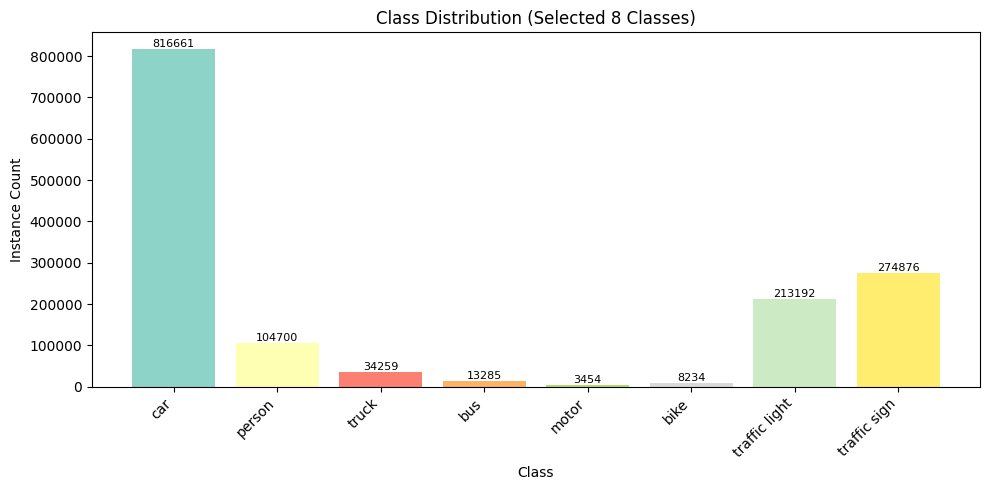

Class counts:
  car: 816661
  person: 104700
  truck: 34259
  bus: 13285
  motor: 3454
  bike: 8234
  traffic light: 213192
  traffic sign: 274876


In [6]:
import importlib
import src.utils
importlib.reload(src.utils) # This forces Python to look at the new version of the file
from src.utils import CLASS_MAP, CLASS_NAMES

class_counts = Counter()
for item in all_annotations:
    for obj in item.get("labels", []):
        cat = obj.get("category")
        if cat in CLASS_MAP:
            class_counts[cat] += 1

classes = list(CLASS_MAP.keys())
counts = [class_counts[c] for c in classes]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(classes, counts, color=["#" + "".join([f"{c:02x}" for c in CLASS_NAMES[i] and (0,0,0)]) for i in range(len(classes))] if False else plt.cm.Set3(np.linspace(0, 1, len(classes))))
ax.set_xlabel("Class")
ax.set_ylabel("Instance Count")
ax.set_title("Class Distribution (Selected 8 Classes)")
plt.xticks(rotation=45, ha="right")
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(count),
            ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PLOTS, "class_distribution.png"), dpi=150)
plt.show()
print("Class counts:")
for c, n in zip(classes, counts):
    print(f"  {c}: {n}")

## 4.2 Bounding Box Statistics

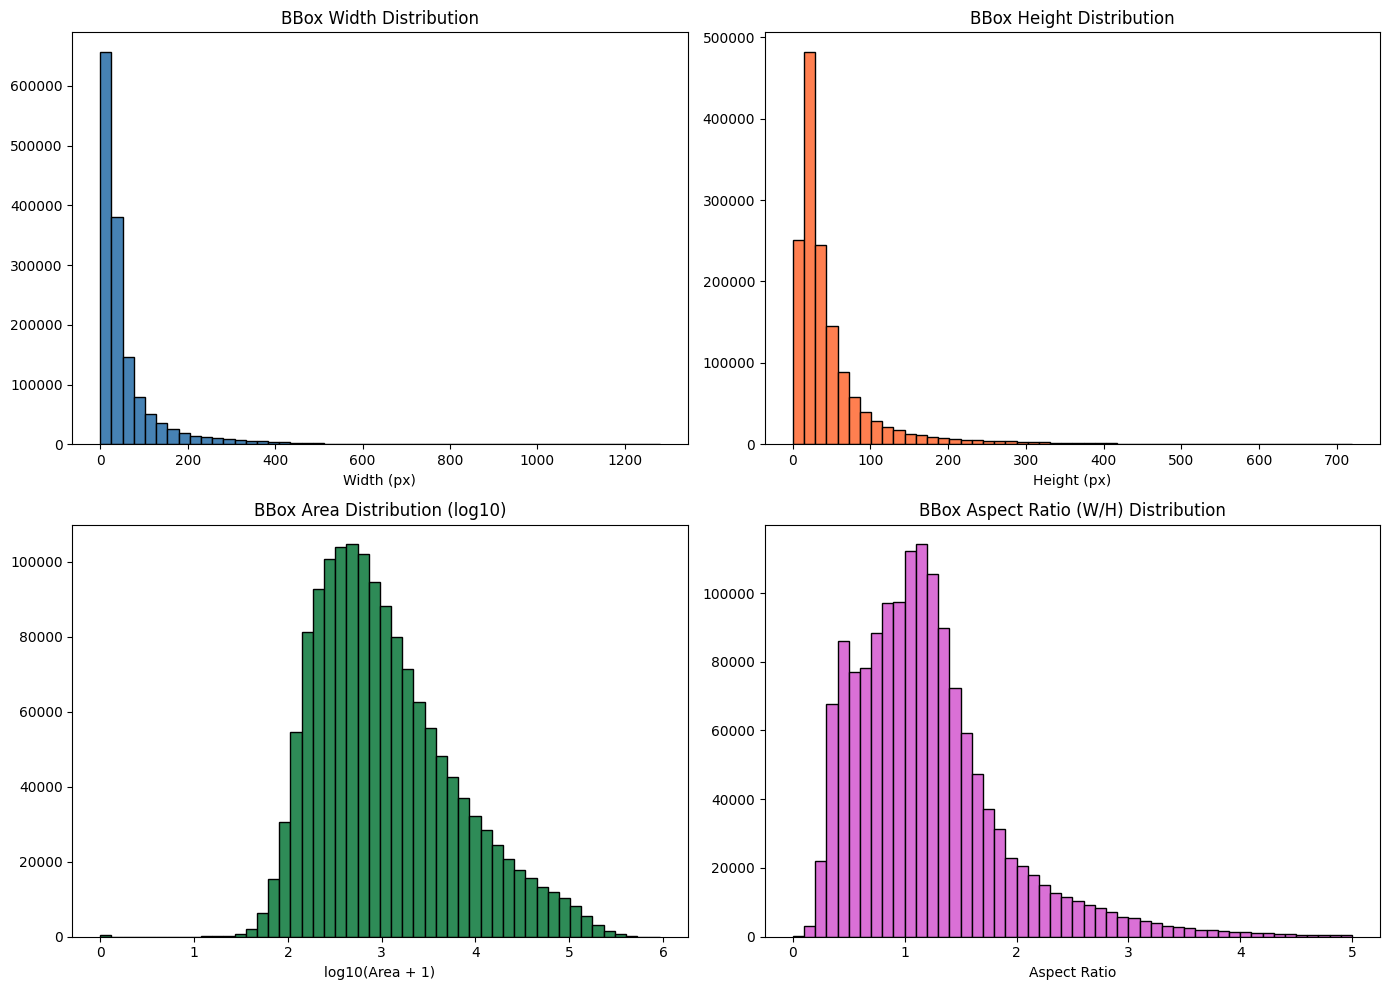

In [7]:
bbox_widths = []
bbox_heights = []
bbox_areas = []
bbox_aspect_ratios = []
objects_per_image = []

for item in all_annotations:
    labels = item.get("labels", [])
    relevant = [obj for obj in labels if obj.get("category") in CLASS_MAP and "box2d" in obj]
    objects_per_image.append(len(relevant))
    for obj in relevant:
        box = obj["box2d"]
        w = box["x2"] - box["x1"]
        h = box["y2"] - box["y1"]
        bbox_widths.append(w)
        bbox_heights.append(h)
        bbox_areas.append(w * h)
        bbox_aspect_ratios.append(w / max(h, 1))

bbox_widths = np.array(bbox_widths)
bbox_heights = np.array(bbox_heights)
bbox_areas = np.array(bbox_areas)
bbox_aspect_ratios = np.array(bbox_aspect_ratios)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(bbox_widths, bins=50, color="steelblue", edgecolor="black")
axes[0, 0].set_title("BBox Width Distribution")
axes[0, 0].set_xlabel("Width (px)")

axes[0, 1].hist(bbox_heights, bins=50, color="coral", edgecolor="black")
axes[0, 1].set_title("BBox Height Distribution")
axes[0, 1].set_xlabel("Height (px)")

axes[1, 0].hist(np.log10(bbox_areas + 1), bins=50, color="seagreen", edgecolor="black")
axes[1, 0].set_title("BBox Area Distribution (log10)")
axes[1, 0].set_xlabel("log10(Area + 1)")

axes[1, 1].hist(bbox_aspect_ratios, bins=50, range=(0, 5), color="orchid", edgecolor="black")
axes[1, 1].set_title("BBox Aspect Ratio (W/H) Distribution")
axes[1, 1].set_xlabel("Aspect Ratio")

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PLOTS, "bbox_size_distribution.png"), dpi=150)
plt.show()

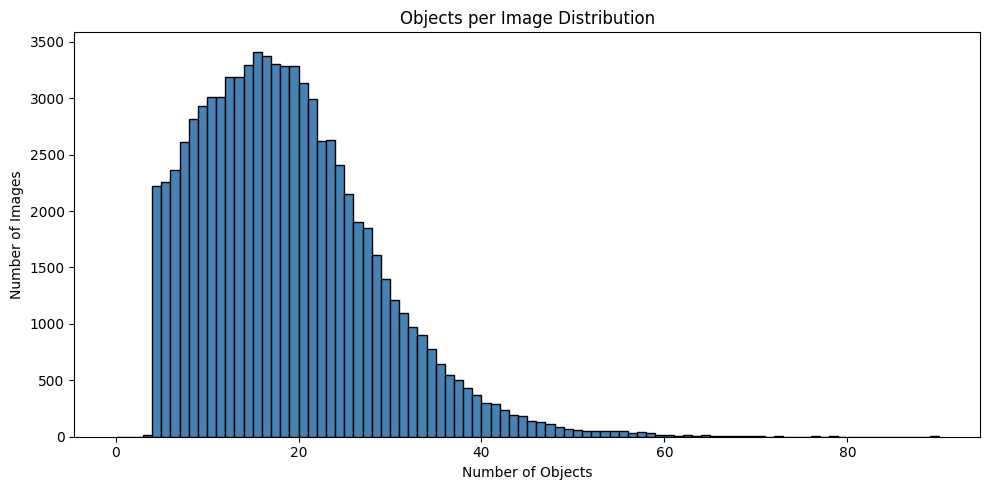

Mean objects/image: 18.36
Median objects/image: 17.00


In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(objects_per_image, bins=range(0, max(objects_per_image) + 2), color="steelblue", edgecolor="black")
ax.set_title("Objects per Image Distribution")
ax.set_xlabel("Number of Objects")
ax.set_ylabel("Number of Images")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PLOTS, "objects_per_image.png"), dpi=150)
plt.show()
print(f"Mean objects/image: {np.mean(objects_per_image):.2f}")
print(f"Median objects/image: {np.median(objects_per_image):.2f}")

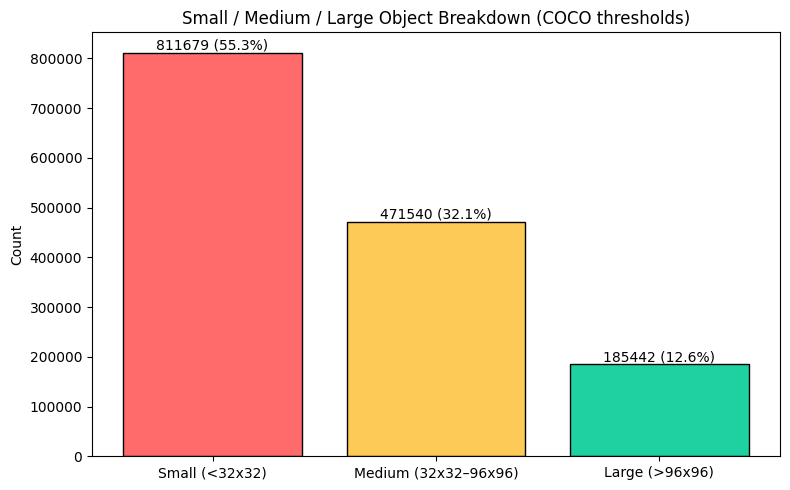

In [9]:
SMALL_THRESH = 32 * 32
MEDIUM_THRESH = 96 * 96

small = np.sum(bbox_areas < SMALL_THRESH)
medium = np.sum((bbox_areas >= SMALL_THRESH) & (bbox_areas < MEDIUM_THRESH))
large = np.sum(bbox_areas >= MEDIUM_THRESH)
total = len(bbox_areas)

fig, ax = plt.subplots(figsize=(8, 5))
categories = ["Small (<32x32)", "Medium (32x32–96x96)", "Large (>96x96)"]
values = [small, medium, large]
colors = ["#ff6b6b", "#feca57", "#1dd1a1"]
bars = ax.bar(categories, values, color=colors, edgecolor="black")
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"{val} ({val/total*100:.1f}%)", ha="center", va="bottom")
ax.set_ylabel("Count")
ax.set_title("Small / Medium / Large Object Breakdown (COCO thresholds)")
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PLOTS, "small_medium_large_breakdown.png"), dpi=150)
plt.show()

## 4.3 Condition Distribution

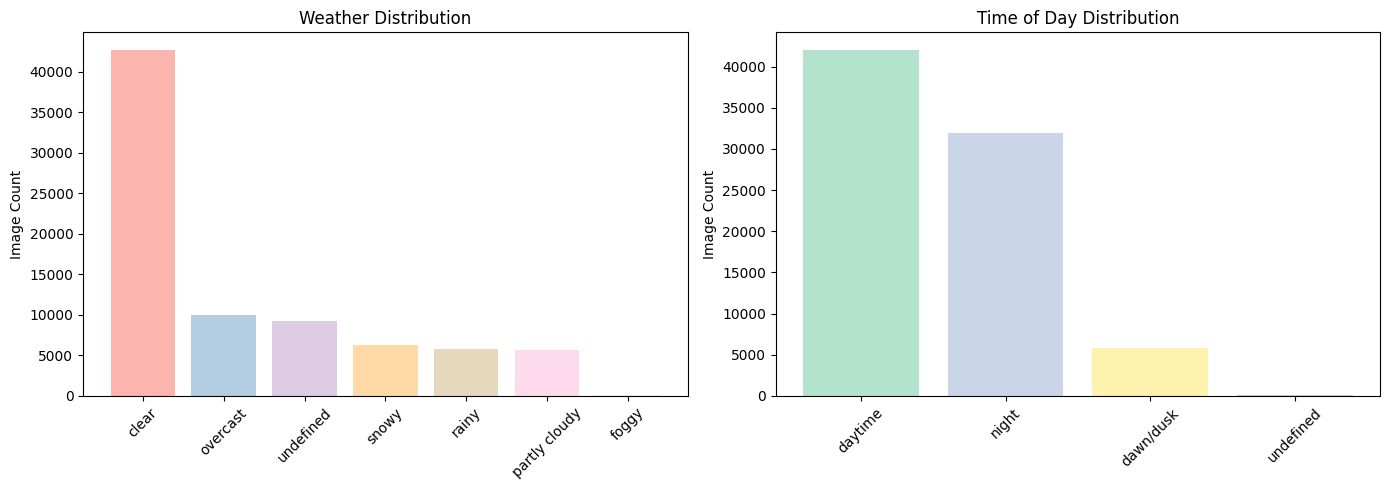

In [10]:
weather_counts = Counter()
timeofday_counts = Counter()

for item in all_annotations:
    attrs = item.get("attributes", {})
    weather_counts[attrs.get("weather", "unknown")] += 1
    timeofday_counts[attrs.get("timeofday", "unknown")] += 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

w_labels, w_values = zip(*weather_counts.most_common())
axes[0].bar(w_labels, w_values, color=plt.cm.Pastel1(np.linspace(0, 1, len(w_labels))))
axes[0].set_title("Weather Distribution")
axes[0].set_ylabel("Image Count")
axes[0].tick_params(axis="x", rotation=45)

t_labels, t_values = zip(*timeofday_counts.most_common())
axes[1].bar(t_labels, t_values, color=plt.cm.Pastel2(np.linspace(0, 1, len(t_labels))))
axes[1].set_title("Time of Day Distribution")
axes[1].set_ylabel("Image Count")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PLOTS, "condition_distribution.png"), dpi=150)
plt.show()

## 4.4 Image Quality Preview

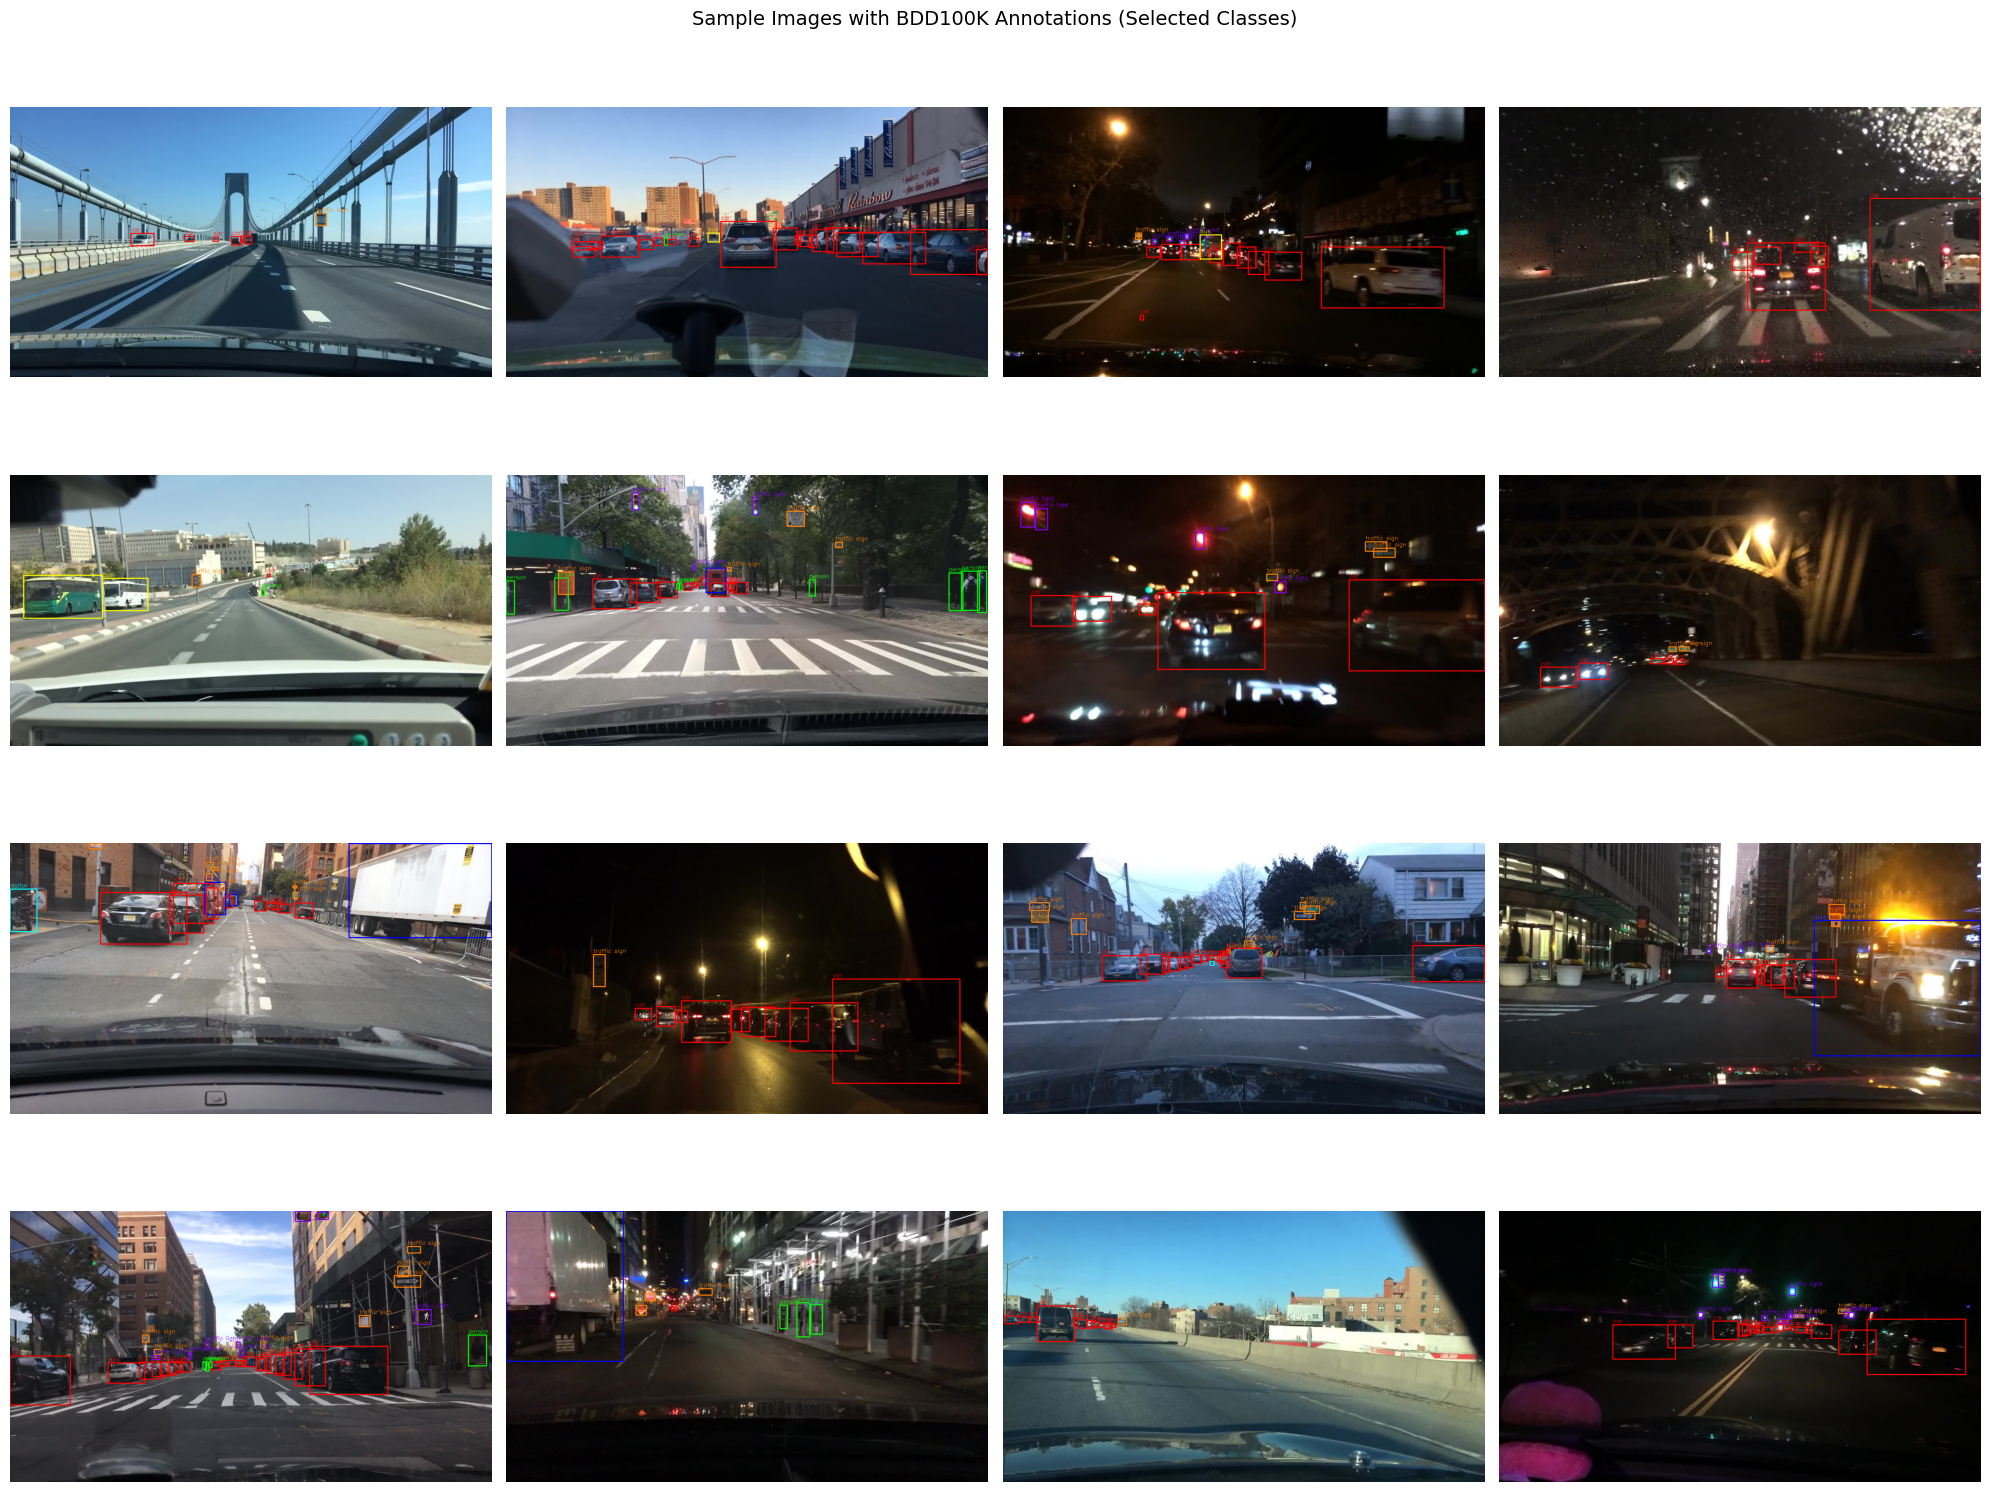

In [11]:
sample_items = random.sample(all_annotations, 16)

fig, axes = plt.subplots(4, 4, figsize=(20, 16))

for ax, item in zip(axes.flat, sample_items):
    img_name = item["name"]
    
    train_path = os.path.join(TRAIN_IMAGE_DIR, img_name)
    val_path = os.path.join(VAL_IMAGE_DIR, img_name)
    
    # Check which path actually exists
    if os.path.exists(train_path):
        img_path = train_path
    elif os.path.exists(val_path):
        img_path = val_path
    else:
        if not img_name.lower().endswith(".jpg"):
            img_name_ext = img_name + ".jpg"
            train_path_ext = os.path.join(TRAIN_IMAGE_DIR, img_name_ext)
            val_path_ext = os.path.join(VAL_IMAGE_DIR, img_name_ext)
            
            if os.path.exists(train_path_ext):
                img_path = train_path_ext
            elif os.path.exists(val_path_ext):
                img_path = val_path_ext
            else:
                img_path = None
        else:
            img_path = None

    # 2. Draw and show if path is valid
    if img_path:
        annotated = draw_bdd100k_labels(img_path, item.get("labels", []))
        if annotated is not None:
            ax.imshow(annotated)
        else:
            ax.text(0.5, 0.5, "Read Error", ha='center')
    else:
        ax.text(0.5, 0.5, f"Not Found:\n{img_name}", ha='center', fontsize=8, color='red')
    
    ax.axis("off")

plt.suptitle("Sample Images with BDD100K Annotations (Selected Classes)", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_PLOTS, "sample_images_preview.png"), dpi=150)
plt.show()

## Save EDA Summary

In [12]:
summary = {
    "total_images": len(all_annotations),
    "total_selected_instances": sum(counts),
    "mean_bbox_width": float(np.mean(bbox_widths)),
    "mean_bbox_height": float(np.mean(bbox_heights)),
    "mean_bbox_area": float(np.mean(bbox_areas)),
    "mean_objects_per_image": float(np.mean(objects_per_image)),
    "small_objects_pct": float(small / total * 100),
    "medium_objects_pct": float(medium / total * 100),
    "large_objects_pct": float(large / total * 100),
}
for cls_name, count in zip(classes, counts):
    summary[f"count_{cls_name.replace(' ', '_')}"] = count

pd.DataFrame([summary]).to_csv(os.path.join(RESULTS_METRICS, "eda_summary.csv"), index=False)
print("EDA summary saved.")
print(json.dumps(summary, indent=2))

EDA summary saved.
{
  "total_images": 80000,
  "total_selected_instances": 1468661,
  "mean_bbox_width": 56.578673451530335,
  "mean_bbox_height": 49.766280930126825,
  "mean_bbox_area": 6768.810942550719,
  "mean_objects_per_image": 18.3582625,
  "small_objects_pct": 55.26659998461183,
  "medium_objects_pct": 32.106796599079026,
  "large_objects_pct": 12.62660341630914,
  "count_car": 816661,
  "count_person": 104700,
  "count_truck": 34259,
  "count_bus": 13285,
  "count_motor": 3454,
  "count_bike": 8234,
  "count_traffic_light": 213192,
  "count_traffic_sign": 274876
}
